# Retail Data Analysis – Visualization & Insights

This notebook is responsible for:
- Calling Flask API endpoints
- Converting JSON responses into Pandas DataFrames
- Visualizing business insights using charts


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# pip install numpy pandas matplotlib seaborn requests



In [2]:
sns.set_theme(
    style="darkgrid",
    context="talk"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13



In [3]:
BASE_URL = "http://127.0.0.1:5000"


In [4]:
resp = requests.get(f"{BASE_URL}/top-customers")
data = resp.json()

In [5]:
df_customers = pd.DataFrame(data)
df_customers


,city,customer_id,customer_name,gender,monthly_spending,preferred_branch,top_products,total_orders,total_spent
0,Giza,10099,Khaled Kamel,Male,"{'2022-02': 104413.38, '2022-03': 75827.7, '20...",Haram Branch,"[{'product_name': 'Furniture Product 4043', 'q...",9,95556.26
1,Ismailia,8636,Mariam Youssef,Female,"{'2022-01': 126242.54999999999, '2022-04': 337...",El Maadi Degla Branch,"[{'product_name': 'Sports Product 16738', 'qua...",10,93448.75
2,Alexandria,7664,Ahmed Kamel,Male,"{'2022-07': 59171.149999999994, '2022-09': 901...",Talkha Branch,"[{'product_name': 'Beauty Product 49015', 'qua...",8,90775.39
3,Mansoura,7287,Mariam Mahmoud,Female,"{'2022-04': 25312.350000000002, '2022-10': 790...",New Fayoum Branch,"[{'product_name': 'Stationery Product 35819', ...",8,84686.83
4,Giza,11334,Aya Ibrahim,Female,"{'2022-03': 68726.0, '2022-07': 33063.04999999...",Shibin El Qanater Branch,"[{'product_name': 'Groceries Product 11282', '...",9,80320.33


### Top Customers (Highest Spenders)


In [6]:
df_customers_top = df_customers.sort_values("total_spent", ascending=False).head(10)

plt.figure(figsize=(10, 6))
palette = sns.color_palette("Blues_r", n_colors=len(df_customers_top))


<Figure size 1000x600 with 0 Axes>

C:\Users\CS\AppData\Local\Temp\ipykernel_14928\2729020072.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


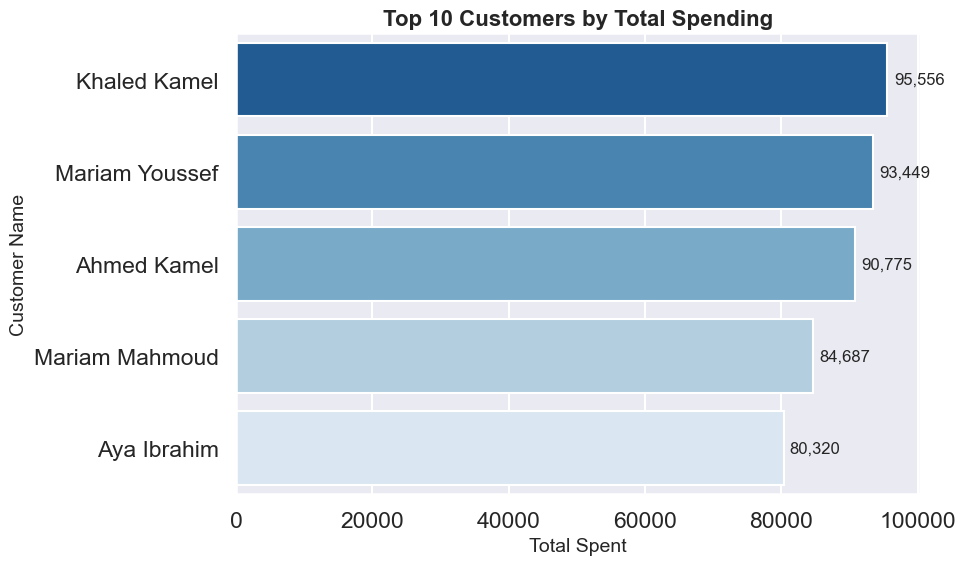

In [7]:
sns.barplot(
    data=df_customers_top,
    x="total_spent",
    y="customer_name",
    palette=palette
)

plt.title("Top 10 Customers by Total Spending", fontweight="bold", fontsize=16)
plt.xlabel("Total Spent", fontsize=14)
plt.ylabel("Customer Name", fontsize=14)

# إضافة القيم بجانب نهاية الأعمدة مع مسافة صغيرة لتحسين القراءة
for i, value in enumerate(df_customers_top["total_spent"]):
    plt.text(
        value + (value * 0.01),  # مسافة 1% من القيمة يمين العمود
        i,
        f"{value:,.0f}",
        va="center",
        ha="left",
        fontsize=12
    )

    plt.tight_layout()
plt.show()

## Best-Selling Products (Overall)

In [8]:
resp = requests.get(f"{BASE_URL}/best-products")
data = resp.json()
df_products = pd.DataFrame(data)
df_products



,product_name,total_quantity
0,Stationery Product 928,54
1,Furniture Product 2442,48
2,Electronics Product 6233,46
3,Home Appliances Product 36958,45
4,Groceries Product 45306,45


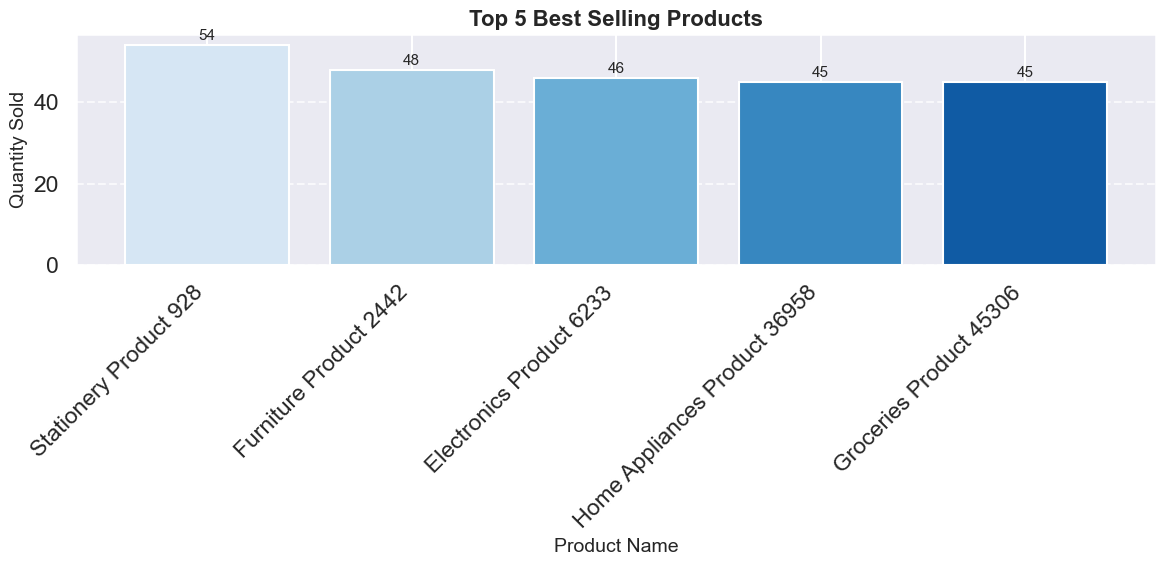

In [9]:
# اختيار أعلى 15 منتجًا حسب الكمية المباعة
df_top_products = df_products.sort_values("total_quantity", ascending=False).head(5)

plt.figure(figsize=(12, 6))

colors = sns.color_palette("hsv", len(df_products))
# استخدام لوحة ألوان متدرجة هادئة وعدد ألوان يساوي عدد المنتجات المعروضة
palette = sns.color_palette("Blues", n_colors=len(df_top_products))



bars = plt.bar(
    df_top_products["product_name"],
    df_top_products["total_quantity"],
    color=palette
)

plt.title("Top 5 Best Selling Products", fontsize=16, fontweight='bold')
plt.xlabel("Product Name", fontsize=14)
plt.ylabel("Quantity Sold", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.01),
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()


 ### Best-Selling Products by Branch

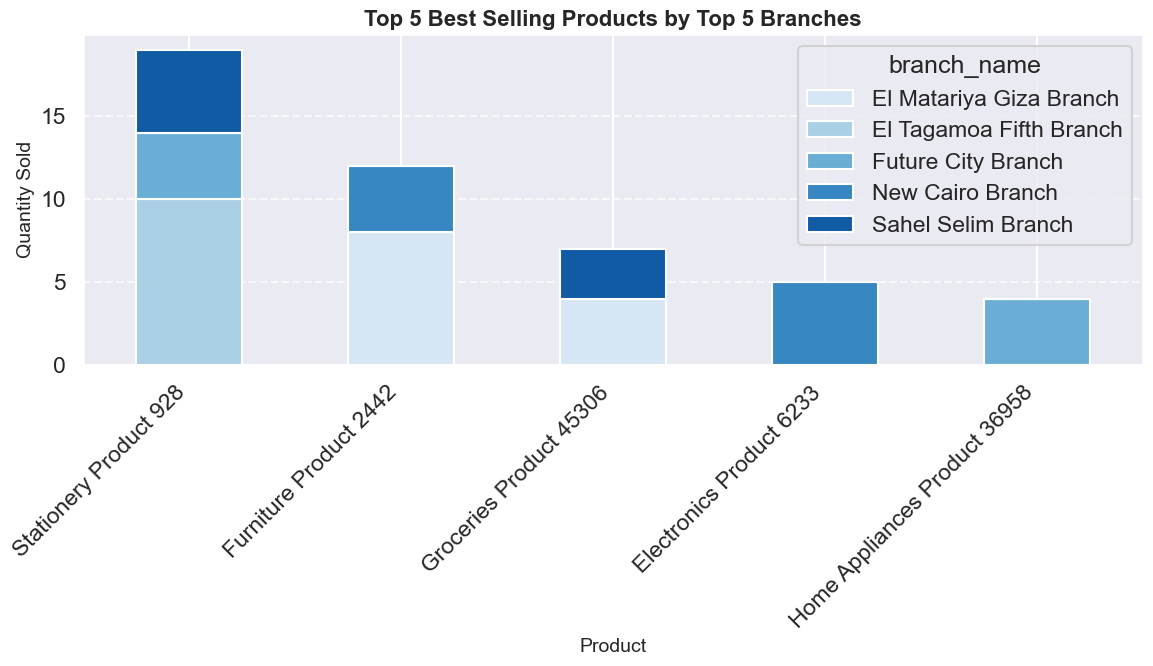

In [10]:
# جلب البيانات وتحويلها إلى DataFrame
resp = requests.get(f"{BASE_URL}/best-products-by-branch")
df_bp = pd.DataFrame(resp.json())

# اختيار أعلى 5 منتجات حسب إجمالي الكمية عبر كل الفروع
top_products = (
    df_bp.groupby("product_name")["total_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# فلترة البيانات لتشمل فقط المنتجات الأعلى
df_top = df_bp[df_bp["product_name"].isin(top_products)]

# اختيار أعلى 5 فروع حسب مجموع الكميات لهذه المنتجات لتقليل الفوضى
top_branches = (
    df_top.groupby("branch_name")["total_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# فلترة البيانات لأفضل الفروع فقط
df_top = df_top[df_top["branch_name"].isin(top_branches)]

# تحويل البيانات لمصفوفة مناسبة للرسم (pivot)
pivot = df_top.pivot_table(
    index="product_name",
    columns="branch_name",
    values="total_quantity",
    fill_value=0
)

# ترتيب المنتجات تنازليًا حسب إجمالي الكمية
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# تحديد ألوان لكل فرع باستخدام لوحة tab20 لتناسب حتى 20 لون
colors = sns.color_palette("Blues", n_colors=len(df_top_products))


# رسم مخطط أعمدة مكدسة stacked barplot
ax = pivot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12, 7)
)

plt.title("Top 5 Best Selling Products by Top 5 Branches", fontsize=16, fontweight='bold')
plt.xlabel("Product", fontsize=14)
plt.ylabel("Quantity Sold", fontsize=14)

# تدوير أسماء المنتجات لتحسين القراءة
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Branch Comparisons (Revenue)


In [11]:
resp = requests.get(f"{BASE_URL}/branch-revenue")
data = resp.json()

df_branch = pd.DataFrame(data)
df_branch


,branch_name,total_revenue
0,Abbasia Branch,9148565.04
1,Farshout Branch,9012150.04
2,Shibin El Kom Branch,8779901.01
3,Ashmoun Branch,8747262.61
4,Fayoum Branch,8677125.58
...,...,...
195,El Minya New Branch,6177499.71
196,Kom Ombo Branch,6170107.46
197,New Ismailia Branch,6159661.86
198,Farafra Branch,6059108.71


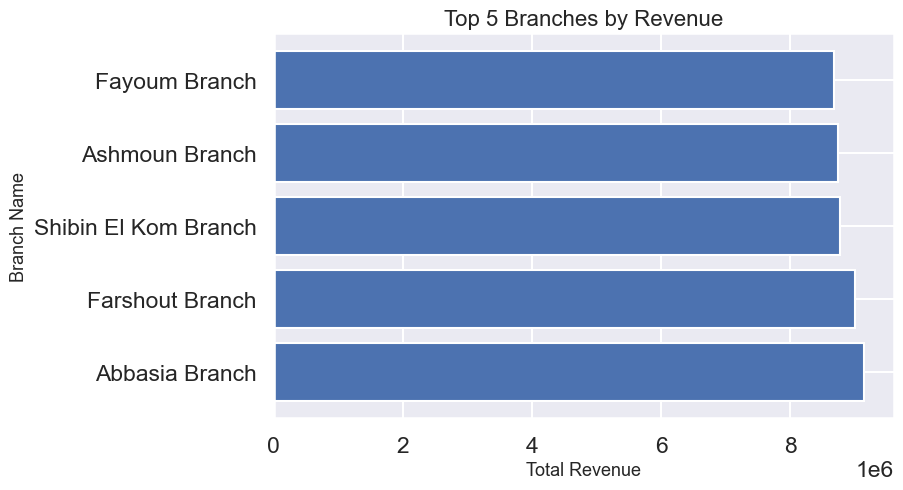

In [12]:
df_branch_sorted = df_branch.sort_values(
    by="total_revenue",
    ascending=False
).head(5)

plt.figure(figsize=(8, 5))
plt.barh(
    df_branch_sorted["branch_name"],
    df_branch_sorted["total_revenue"]
)
plt.title("Top 5 Branches by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Branch Name")
plt.grid(True)
plt.show()


### Time Analysis (Monthly/Seasonal Trends)

In [13]:
# جلب البيانات وتحويلها إلى DataFrame
resp = requests.get(f"{BASE_URL}/monthly-sales")
df_time = pd.DataFrame(resp.json())


# تحويل الشهر إلى datetime وترتيب زمني
df_time["month"] = pd.to_datetime(df_time["month"])
df_time = df_time.sort_values("month")
df_time

,month,total_sales
0,2022-01-01,42032212.94
1,2022-02-01,38190615.09
2,2022-03-01,42480935.94
3,2022-04-01,41537095.05
4,2022-05-01,41320485.14
5,2022-06-01,42058371.85
6,2022-07-01,42708046.54
7,2022-08-01,41638950.41
8,2022-09-01,38326013.88
9,2022-10-01,44260405.67


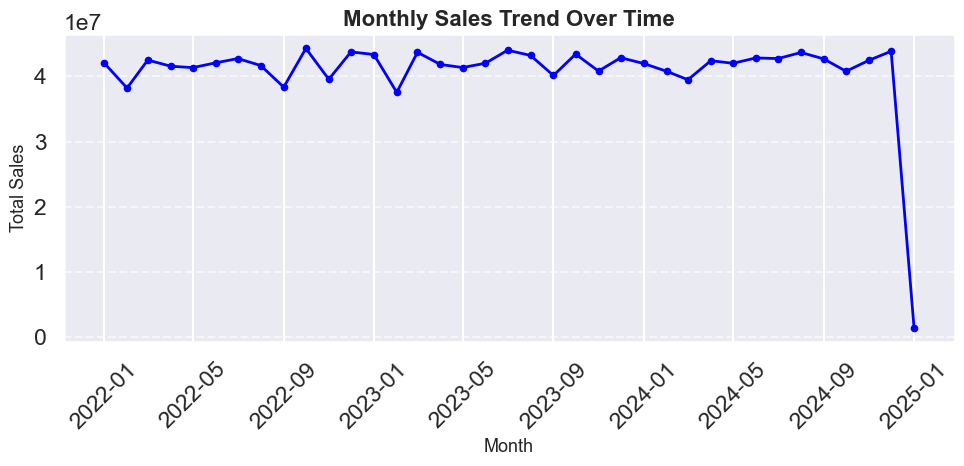

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_time["month"],
    df_time["total_sales"],
    color="blue",
    marker=".",
    linewidth=2
)

plt.title("Monthly Sales Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


### Seasonal Product Demand


In [15]:
# جلب البيانات
resp = requests.get(f"{BASE_URL}/seasonal-product-demand")
df_seasonal = pd.DataFrame(resp.json())

# تحويل الشهر
df_seasonal["month"] = pd.to_datetime(df_seasonal["month"])
df_seasonal["month_name"] = df_seasonal["month"].dt.month_name()

# ترتيب الشهور
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# اختيار أعلى 10 منتجات
top_products = (
    df_seasonal.groupby("product_name")["total_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = df_seasonal[df_seasonal["product_name"].isin(top_products)]

# تجميع موسمي
pivot = (
    df_top.groupby(["product_name", "month_name"])["total_quantity"]
    .mean()
    .reset_index()
    .pivot(
        index="product_name",
        columns="month_name",
        values="total_quantity"
    )
    .reindex(columns=month_order)
)

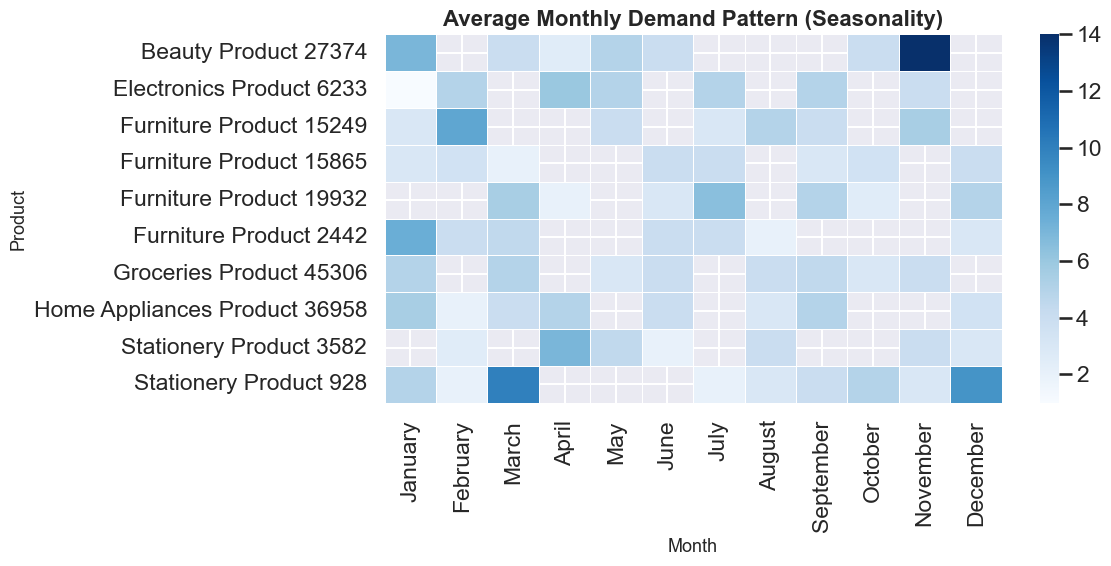

In [16]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    cmap="Blues",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Average Monthly Demand Pattern (Seasonality)", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


### Stock Planning

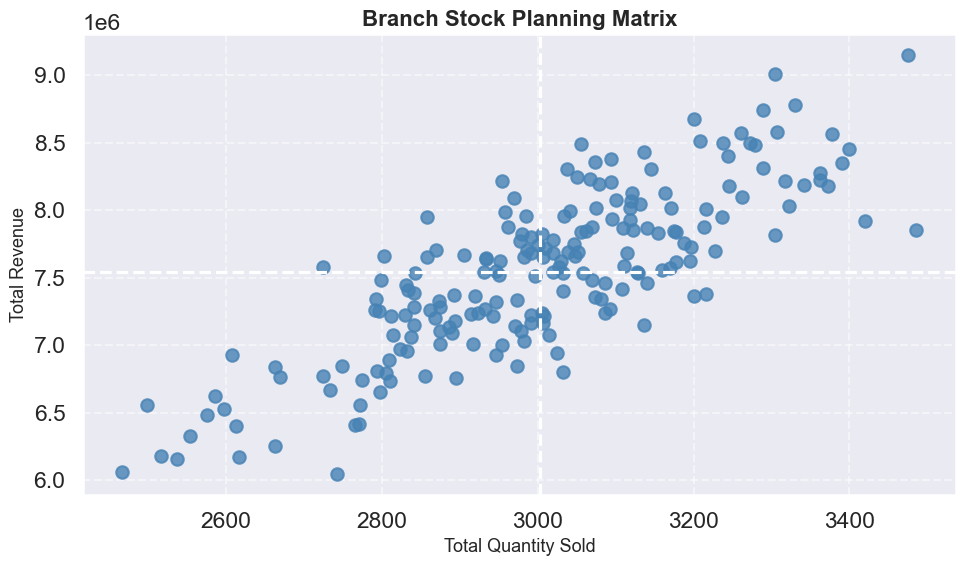

In [17]:
# جلب البيانات
resp = requests.get(f"{BASE_URL}/stock-planning")
df_stock = pd.DataFrame(resp.json())

# حساب المتوسطات لتقسيم الرسم
avg_quantity = df_stock["total_quantity"].mean()
avg_revenue = df_stock["total_revenue"].mean()

plt.figure(figsize=(10, 6))

plt.scatter(
    df_stock["total_quantity"],
    df_stock["total_revenue"],
    color="steelblue",
    alpha=0.8
)

# خطوط التقسيم
plt.axvline(avg_quantity, linestyle="--")
plt.axhline(avg_revenue, linestyle="--")

plt.title("Branch Stock Planning Matrix", fontsize=16, fontweight="bold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")

plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
